## Решение задачи регрессии: предсказать число (по аналогии с классификацией)

## 1. Импорт библиотек

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

## 2. Создание и визуализация датасета

Создадим искусственный датасет из четырех классов точек на плоскости:

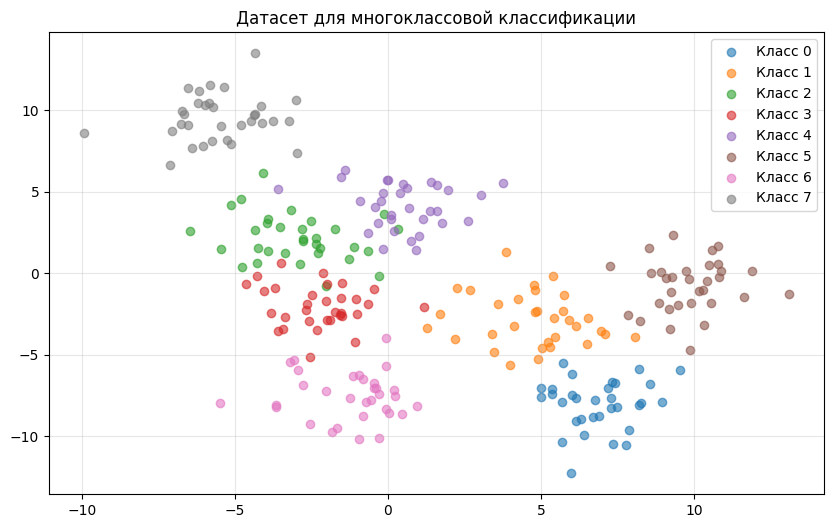

Размер обучающей выборки: (192, 2)
Размер тестовой выборки: (64, 2)
Распределение классов: [32 32 32 32 32 32 32 32]


In [141]:
# Создаем датасет с четырьмя классами
n_samples = 256 # Кол-во точек
n_features = 2 # Кол-во координат (признаков)
n_classes = 8

X, y = make_blobs( # X - матрица признаков, y - вектор ответов от 0 до 3
    n_samples=n_samples,
    n_features=n_features,
    centers=n_classes,
    cluster_std=1.42,
    random_state=44
)
y_reg = y.astype(np.float32).reshape(-1, 1)

# Масштабируем данные в диапазон [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_reg, test_size=0.25, random_state=42
)

# Визуализация датасета
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.scatter(X[y == i, 0], X[y == i, 1], 
                alpha=0.6, label=f'Класс {i}')

plt.title("Датасет для многоклассовой классификации")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов: {np.bincount(y)}")

## 5. Создание модели PyTorch

In [142]:
import torch.nn as nn

class RegressionModel(nn.Module):
    def __init__(self, input_dim=n_features, output_dim=1):
        super(RegressionModel, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # Один выход для предсказания значения
        )
        
    def forward(self, x):
        return self.net(x)

    def predict(self, x):
        with torch.no_grad():
            output = self.forward(x)
            return torch.round(output)

model = RegressionModel(input_dim=2, output_dim=1)

print("Архитектура модели:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params}")
print(f"Обучаемых параметров: {trainable_params}")

Архитектура модели:
RegressionModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Всего параметров: 8577
Обучаемых параметров: 8577


## 6. Подготовка данных для PyTorch

In [ ]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_reg = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_reg = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

batch_size = 1

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Проверка того, что всё собрано верно
print(f"Форма X_train: {X_train_tensor.shape}") # Должно быть [192, 2]
print(f"Форма y_train: {y_train_reg.shape}")    # Должно быть [192, 1]
print(f"Размер батча: {batch_size}")
print(f"Количество батчей в обучающей выборке: {len(train_loader)}")
print(f"Количество батчей в тестовой выборке: {len(test_loader)}")

Форма X_train: torch.Size([192, 2])
Форма y_train: torch.Size([192, 1])
Размер батча: 1
Количество батчей в обучающей выборке: 6
Количество батчей в тестовой выборке: 2


## 7. Обучение модели

In [ ]:
def train_model(model, train_loader, test_loader, epochs=50, learning_rate=0.01):
    # Для регрессии используем MSE
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []
    
    print("Начинаем обучение (регрессия с метрикой Accuracy)...")
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        train_correct = 0
        train_total = 0
        
        for _, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            
            output = model(data)
            loss = loss_function(output, target)
            
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            
            # ВЫЧИСЛЕНИЕ ACCURACY ДЛЯ РЕГРЕССИИ:
            # Округляем предсказанное число до ближайшего целого
            predicted = torch.round(output.data) 
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        
        model.eval()
        total_test_loss = 0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                output = model(data)
                loss = loss_function(output, target)
                total_test_loss += loss.item()
                
                # Округляем для проверки точности на тесте
                predicted = torch.round(output.data)
                test_total += target.size(0)
                test_correct += (predicted == target).sum().item()
        
        avg_test_loss = total_test_loss / len(test_loader)
        test_accuracy = 100 * test_correct / test_total

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        test_losses.append(avg_test_loss)
        test_accuracies.append(test_accuracy)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            clear_output(wait=True)
            print(f"Эпоха {epoch+1}/{epochs}:")
            print(f"  Обучающая выборка: loss={avg_train_loss:.4f}, accuracy={train_accuracy:.2f}%")
            print(f"  Тестовая выборка:  loss={avg_test_loss:.4f}, accuracy={test_accuracy:.2f}%")
    
    print("\nОбучение завершено!")
    
    return train_losses, train_accuracies, test_losses, test_accuracies

epochs = 1000 # Количество эпох обучения (можно изменять)
learning_rate = 0.01 # Скорость обучения (можно изменять)

train_losses, train_maes, test_losses, test_maes = train_model(
    model, train_loader, test_loader, epochs=epochs, learning_rate=learning_rate
)

Эпоха 1000/1000:
  Обучающая выборка: loss=0.1417, accuracy=86.98%
  Тестовая выборка:  loss=0.2641, accuracy=85.94%

Обучение завершено!


## 8. Визуализация процесса обучения

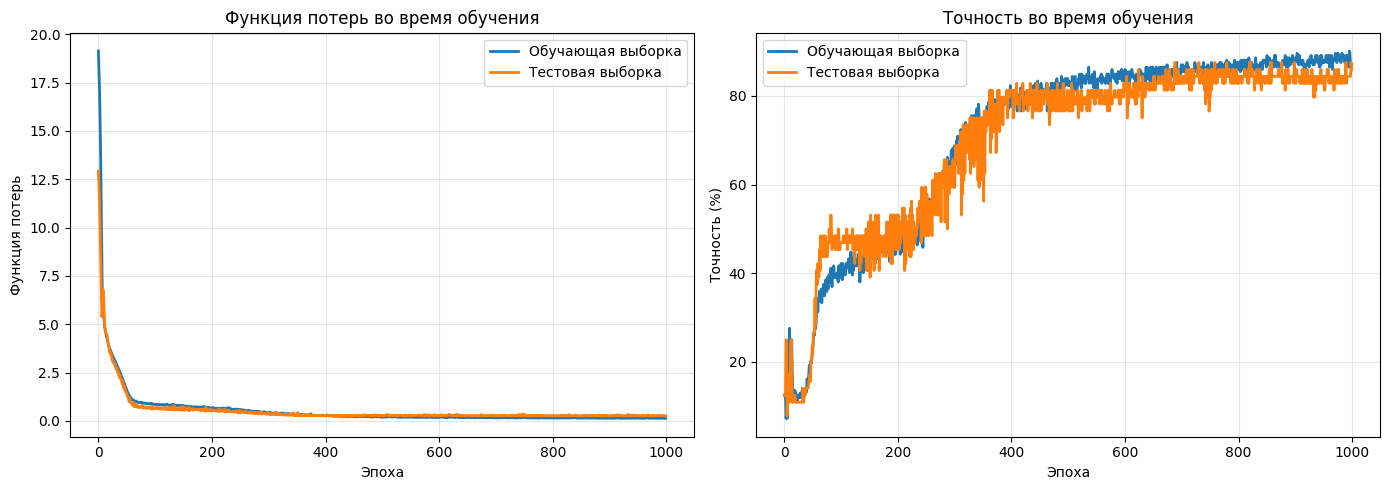

Финальная точность на обучающей выборке: 86.98%
Финальная точность на тестовой выборке: 85.94%


In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Обучающая выборка', linewidth=2)
axes[0].plot(test_losses, label='Тестовая выборка', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Функция потерь')
axes[0].set_title('Функция потерь во время обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_maes, label='Обучающая выборка', linewidth=2)
axes[1].plot(test_maes, label='Тестовая выборка', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность (%)')
axes[1].set_title('Точность во время обучения')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Финальная точность на обучающей выборке: {train_maes[-1]:.2f}%")
print(f"Финальная точность на тестовой выборке: {test_maes[-1]:.2f}%")

## 10. Визуализация границ решения

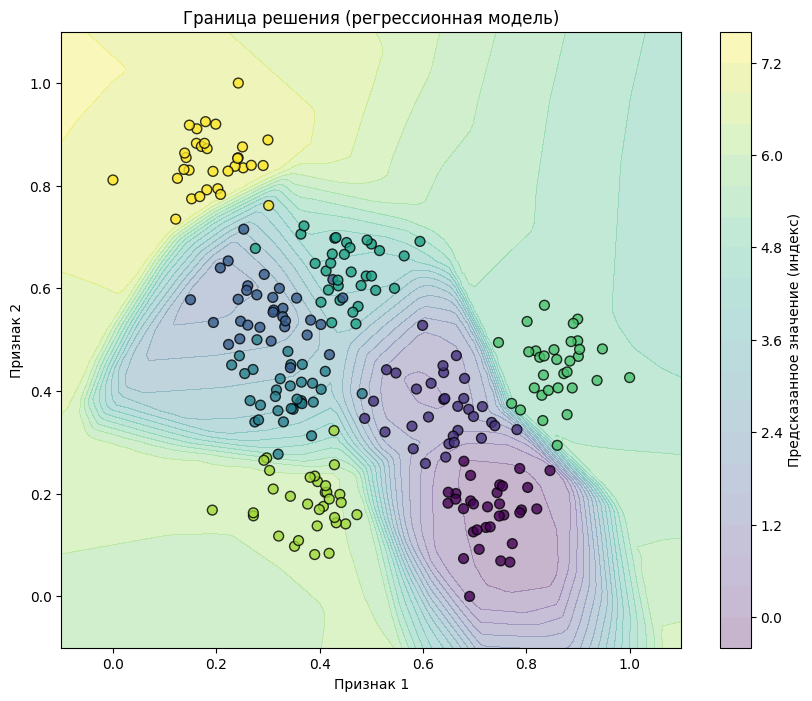

In [146]:
def plot_decision_boundary(model, X, y, title="Поверхность решений регрессии"):
    # Создаем сетку (как и раньше)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        # В регрессии мы просто вызываем модель (без predict_proba)
        Z = model(grid_tensor)
        
    Z = Z.numpy().reshape(xx.shape)

    plt.figure(figsize=(10, 8))

    # Рисуем непрерывную поверхность предсказанных значений
    # Используем pcolormesh или contourf для отображения "интенсивности" значения
    contour = plt.contourf(xx, yy, Z, levels=20, alpha=0.3, cmap='viridis')
    
    # Рисуем исходные точки
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                          edgecolors='k', s=50, alpha=0.8)
    
    plt.title(title)
    plt.colorbar(contour, label='Предсказанное значение (индекс)')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    
    plt.show()

# Визуализация на полном датасете
plot_decision_boundary(model, X_scaled, y, 
                       title="Граница решения (регрессионная модель)")